# Librerías

In [1]:
# Use this initial code to work in the notebook as if it were a module, that 
# is, to be able to export classes and functions from other subpackages.

import os
import sys

package_path = os.path.abspath('.').split(os.sep + 'notebooks')[0]
if package_path not in sys.path:
    sys.path.append(package_path)

%load_ext autoreload
%autoreload 2

# 0. Imports, configuración, utilidades


In [2]:
import os
from pathlib import Path

import dask.array as da
from dask.diagnostics import ProgressBar

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import numpy as np
import pandas as pd
import xarray as xr

from spectralcrop import PathManager

INTERIM_DATA = PathManager().get_abs_path_folder("interim")
FIGURES_FOLDER = PathManager().get_abs_path_folder("figures")
ZARR_PATH = INTERIM_DATA + "masked_reflectance.zarr"
REPORTS_DIR = INTERIM_DATA + "reports"
INDICES_DIR = REPORTS_DIR + "/indices"
os.makedirs(REPORTS_DIR, exist_ok=True)
os.makedirs(INDICES_DIR, exist_ok=True)

RNG = np.random.default_rng(42)

def to_numpy(arr):
    return arr.compute() if isinstance(arr.data, da.Array) else arr.values

def nearest_band_index(wavelengths_nm, target_nm):
    wavelengths_nm = np.asarray(wavelengths_nm, dtype=float)
    idx = int(np.abs(wavelengths_nm - target_nm).argmin())
    return idx, float(wavelengths_nm[idx])

In [3]:
INTERIM_DATA, REPORTS_DIR, ZARR_PATH, FIGURES_FOLDER, INDICES_DIR

('c:\\Users\\JMONTOYA\\Documents\\personal_projects\\thesis\\data\\interim\\',
 'c:\\Users\\JMONTOYA\\Documents\\personal_projects\\thesis\\data\\interim\\reports',
 'c:\\Users\\JMONTOYA\\Documents\\personal_projects\\thesis\\data\\interim\\masked_reflectance.zarr',
 'c:\\Users\\JMONTOYA\\Documents\\personal_projects\\thesis\\reports\\figures\\',
 'c:\\Users\\JMONTOYA\\Documents\\personal_projects\\thesis\\data\\interim\\reports/indices')

# 1. Abrir Zarr e inspeccionar

In [4]:
ds = xr.open_zarr(ZARR_PATH, chunks={"band": 64, "y": 512, "x": 512})

# Variables clave (band,y,x) -> transponer a (y,x,band) para trabajar cómodo
refl_byx = ds["reflectance"].transpose("y", "x", "band")
wavelengths = ds["wavelength"].values.astype(float)
fwhm = ds["fwhm"].values.astype(float)
ndvi = ds["NDVI"]
veg_mask = ds["veg_mask"].astype("bool")
written_bands = ds["written_bands"]

print(refl_byx)
print("wavelengths:", wavelengths.shape, "nm  |  fwhm:", fwhm.shape, "nm")
print("NDVI dims:", ndvi.dims, "veg_mask dims:", veg_mask.dims)

# Consistencias útiles para checklist
wl_min, wl_max = float(np.nanmin(wavelengths)), float(np.nanmax(wavelengths))
b_out = int(refl_byx.sizes["band"])
wb_all_ones = bool(int(to_numpy(written_bands).min()) == 1 and int(to_numpy(written_bands).max()) == 1)
print(f"Bandas exportadas: {b_out}, λ: {wl_min:.1f}–{wl_max:.1f} nm, written_bands all=1? {wb_all_ones}")

<xarray.DataArray 'reflectance' (y: 3660, x: 3438, band: 379)> Size: 19GB
dask.array<transpose, shape=(3660, 3438, 379), dtype=float32, chunksize=(512, 512, 64), chunktype=numpy.ndarray>
Coordinates:
  * band     (band) int32 2kB 0 1 2 3 4 5 6 7 ... 372 373 374 375 376 377 378
Dimensions without coordinates: y, x
Attributes:
    dimension_names:    ['band', 'y', 'x']
    _ARRAY_DIMENSIONS:  ['band', 'y', 'x']
wavelengths: (379,) nm  |  fwhm: (379,) nm
NDVI dims: ('y', 'x') veg_mask dims: ('y', 'x')
Bandas exportadas: 379, λ: 411.0–2449.2 nm, written_bands all=1? True


C:\Users\JMONTOYA\AppData\Local\Temp\ipykernel_22960\144975827.py:1: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  ds = xr.open_zarr(ZARR_PATH, chunks={"band": 64, "y": 512, "x": 512})
C:\Users\JMONTOYA\AppData\Local\Temp\ipykernel_22960\144975827.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "band" starting at index 64. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_zarr(ZARR_PATH, chunks={"band": 64, "y": 512, "x": 512})


# 2. Mapa de NoData

In [5]:
# Definición: pixel es NoData si en alguna banda hay NaN
mask_nodata = xr.where(xr.ufuncs.isnan(refl_byx).any(dim="band"), 1, 0).astype("uint8")
mask_nodata.name = "mask_nodata"
mask_nodata.to_dataset().to_zarr(REPORTS_DIR + "/mask_nodata.zarr", mode="w")

total_px = refl_byx.sizes["y"] * refl_byx.sizes["x"]
nodata_count = int(mask_nodata.sum().compute())
print(f"Pixeles NoData: {nodata_count} ({nodata_count/total_px:.2%})")

c:\Users\JMONTOYA\Documents\personal_projects\thesis\.venv\Lib\site-packages\zarr\api\asynchronous.py:244: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


Pixeles NoData: 6484992 (51.54%)


Se tiene que del total de pixeles originales, 51.54% no poseen datos ya que o se encuentran en una zona externa a la imagen capturada o los pixeles son clasificados como información inválida (150000)

# 4. Validación NDVI/veg_mask

In [6]:
# Quick stats para confirmar consistencia
ndvi_stats = ndvi.where(~xr.ufuncs.isnan(ndvi)).quantile([0.01, 0.5, 0.99]).compute()
veg_ratio = float(veg_mask.mean().compute())
print("NDVI percentiles [1%, 50%, 99%]:", to_numpy(ndvi_stats).round(3))
print(f"Proporción de vegetación (veg_mask==True): {veg_ratio:.2%}")

NDVI percentiles [1%, 50%, 99%]: [0.32  0.865 0.927]
Proporción de vegetación (veg_mask==True): 48.70%


Pixeles NoData: 6,484,992 (51.54%)


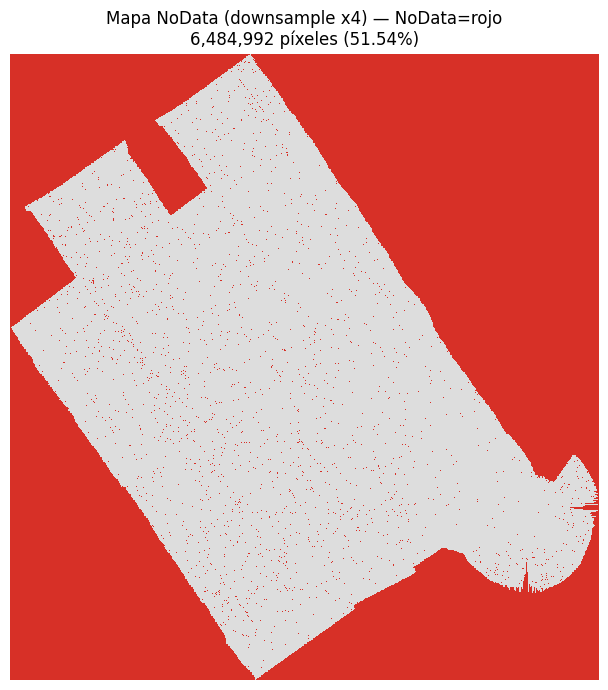

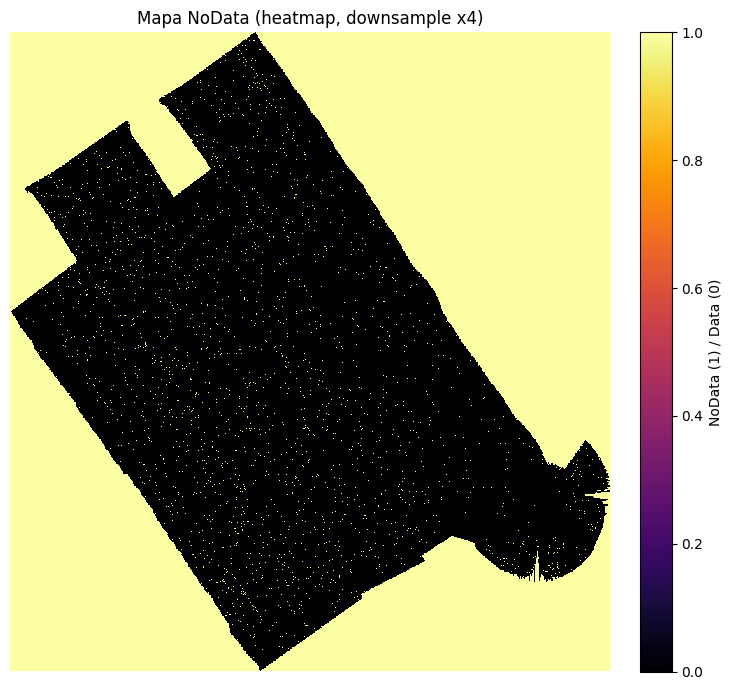

In [ ]:
# --- Mapa visual de píxeles NoData (y superposición opcional de veg_mask) ---

# reflectance está como (band, y, x) -> transponer para operar cómodo
refl = ds["reflectance"].transpose("y", "x", "band")


# 2) Estadísticos rápidos
total_px = mask_nodata.sizes["y"] * mask_nodata.sizes["x"]
nodata_px = int(mask_nodata.sum().compute())
nodata_pct = 100.0 * nodata_px / total_px
print(f"Pixeles NoData: {nodata_px:,} ({nodata_pct:.2f}%)")

# 3) Preparar una versión reducida para visualización rápida (downsample)
stride = 4
nodata_vis = mask_nodata.isel(y=slice(None, None, stride),
                               x=slice(None, None, stride))

# 4) Visualización binaria clara (NoData=1 en rojo, Data=0 en gris claro)
cmap_bin = ListedColormap(["#dddddd", "#d73027"])  # data=gris, NoData=rojo

plt.figure(figsize=(8,7))
im = plt.imshow(nodata_vis, cmap=cmap_bin, interpolation="nearest")
plt.title(f"Mapa NoData (downsample x{stride}) — NoData=rojo\n{nodata_px:,} píxeles ({nodata_pct:.2f}%)")
plt.axis("off")
plt.tight_layout()
plt.savefig(FIGURES_FOLDER + "/nodata_map_binary.png", dpi=150)
plt.show()

# 5) Visualización tipo heatmap
#    Aquí es binario, pero mantenemos un esquema 'heatmap' por consistencia visual.
plt.figure(figsize=(8,7))
im = plt.imshow(nodata_vis, cmap="inferno", interpolation="nearest", vmin=0, vmax=1)
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.set_label("NoData (1) / Data (0)")
plt.title(f"Mapa NoData (heatmap, downsample x{stride})")
plt.axis("off")
plt.tight_layout()
plt.savefig(FIGURES_FOLDER + "/nodata_map_heat.png", dpi=150)
plt.show()

# 5. SNR proxy por banda (sólo vegetación)

[########################################] | 100% Completed | 17.22 s
[########################################] | 100% Completed | 35.22 s
[########################################] | 100% Completed | 12.32 s
[########################################] | 100% Completed | 12.15 s


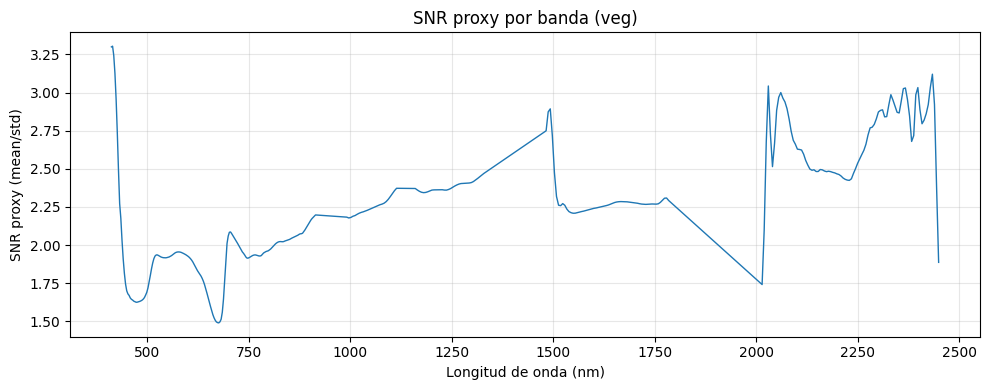

In [ ]:

cube_veg = refl_byx.where(veg_mask & (mask_nodata == 0), np.nan)

with ProgressBar():
    band_mean = cube_veg.mean(dim=("y","x"), skipna=True).compute().values
with ProgressBar():
    band_std = cube_veg.std(dim=("y","x"), skipna=True).compute().values
with ProgressBar():
    band_max = cube_veg.max(dim=("y","x"), skipna=True).compute().values
with ProgressBar():
    band_min = cube_veg.min(dim=("y","x"), skipna=True).compute().values

snr_proxy = band_mean / np.where(band_std == 0, np.nan, band_std)
snr_df = pd.DataFrame({
    "band_index": np.arange(refl_byx.sizes["band"]),
    "wavelength_nm": wavelengths,
    "fwhm_nm": fwhm,
    "mean": band_mean,
    "std": band_std,
    "max": band_max,
    "min": band_min,
    "snr_proxy": snr_proxy
})
snr_df.to_csv(INTERIM_DATA + "/snr_proxy_per_band.csv", index=False)

plt.figure(figsize=(10,4))
plt.plot(wavelengths, snr_proxy, lw=1)
plt.xlabel("Longitud de onda (nm)"); plt.ylabel("SNR proxy (mean/std)")
plt.title("SNR proxy por banda (veg)"); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_FOLDER + "/snr_proxy_curve.png", dpi=150)

[########################################] | 100% Completed | 20.06 s
[########################################] | 100% Completed | 35.89 s
[########################################] | 100% Completed | 12.47 s
[########################################] | 100% Completed | 12.85 s


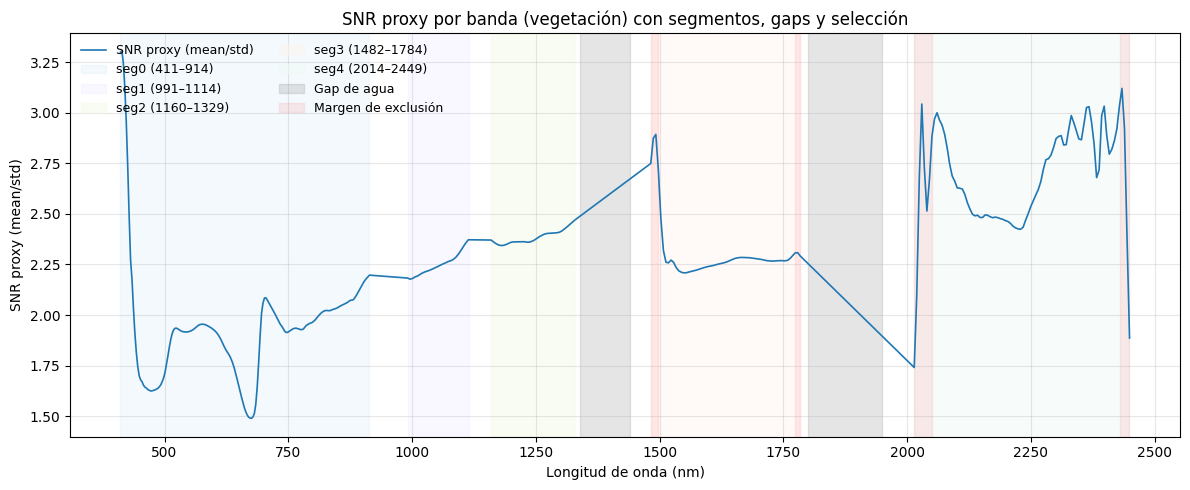

In [ ]:
# --- SNR proxy + overlay de segmentos, gaps y selección de bandas ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dask.diagnostics import ProgressBar
from matplotlib.patches import Patch
from pathlib import Path

# ====== 1) Cálculo SNR proxy (igual a tu código) ======
cube_veg = refl_byx.where(veg_mask & (mask_nodata == 0), np.nan)

with ProgressBar():
    band_mean = cube_veg.mean(dim=("y","x"), skipna=True).compute().values
with ProgressBar():
    band_std = cube_veg.std(dim=("y","x"), skipna=True).compute().values
with ProgressBar():
    band_max = cube_veg.max(dim=("y","x"), skipna=True).compute().values
with ProgressBar():
    band_min = cube_veg.min(dim=("y","x"), skipna=True).compute().values

snr_proxy = band_mean / np.where(band_std == 0, np.nan, band_std)
snr_df = pd.DataFrame({
    "band_index": np.arange(refl_byx.sizes["band"]),
    "wavelength_nm": wavelengths,
    "fwhm_nm": fwhm,
    "mean": band_mean,
    "std": band_std,
    "max": band_max,
    "min": band_min,
    "snr_proxy": snr_proxy
})
# snr_df.to_csv(INTERIM_DATA + "/snr_proxy_per_band.csv", index=False)



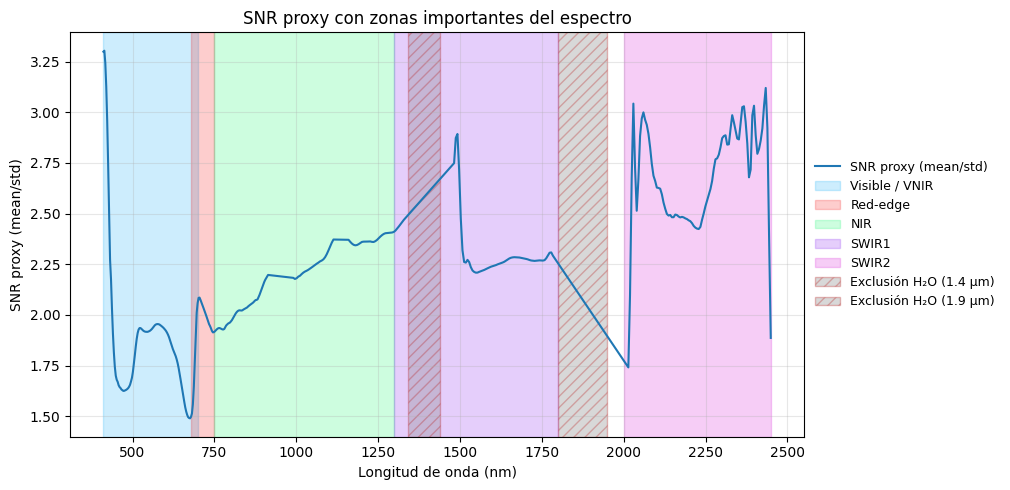

In [78]:
# === Figura: SNR proxy + zonas VNIR/Red-edge/NIR/SWIR, ventanas de índices y EXCLUSIONES por agua/vapor ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.figure(figsize=(12, 5))
plt.plot(wavelengths, snr_proxy, lw=1.5, color="#1f77b4", label="SNR proxy (mean/std)")

# 1) Zonas amplias (sin segmentación técnica)
zones = [
    ("Visible / VNIR", 400.0, 700.0,  "#06a7f7"),
    ("Red-edge",       680.0, 750.0,  "#f50707"),
    ("NIR",            750.0, 1300.0, "#07f763"),
    ("SWIR1",          1300.0, 1800.0,"#7d0cee"),
    ("SWIR2",          2000.0, 2500.0,"#d308d3"),
]
for label, a, b, col in zones:
    left = max(a, float(np.nanmin(wavelengths)))
    right = min(b, float(np.nanmax(wavelengths)))
    if left < right:
        plt.axvspan(left, right, color=col, alpha=0.2, label=label)

# 2) Zonas de EXCLUSIÓN (agua/vapor) — las ventanas que se descartaron en el preprocesado
#    Excluir ~[1340, 1440] y [1800, 1950] nm.
exclusion_windows_nm = [
    ("Exclusión H₂O (1.4 μm)", 1340.0, 1440.0),
    ("Exclusión H₂O (1.9 μm)", 1800.0, 1950.0),
]
for label, a, b in exclusion_windows_nm:
    left = max(a, float(np.nanmin(wavelengths)))
    right = min(b, float(np.nanmax(wavelengths)))
    if left < right:
        # color y hatch distintos para diferenciar claramente de zonas útiles
        plt.axvspan(left, right, color="grey", alpha=0.3, hatch="///", ec="#b71c1c", label=label)

# Leyenda sin duplicados
handles, labels = plt.gca().get_legend_handles_labels()
seen, handles2, labels2 = set(), [], []
for h, l in zip(handles, labels):
    if l not in seen:
        handles2.append(h); labels2.append(l); seen.add(l)
plt.legend(handles2, labels2, loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=9, ncol=1, frameon=False)

plt.xlabel("Longitud de onda (nm)")
plt.ylabel("SNR proxy (mean/std)")
plt.title("SNR proxy con zonas importantes del espectro")
plt.grid(True, alpha=0.3)
plt.tight_layout(rect=[0, 0, 0.85, 1])
# plt.savefig(FIGURES_FOLDER + "/snr_proxy_curve_zonas_exclusiones.png", dpi=150)
plt.show()

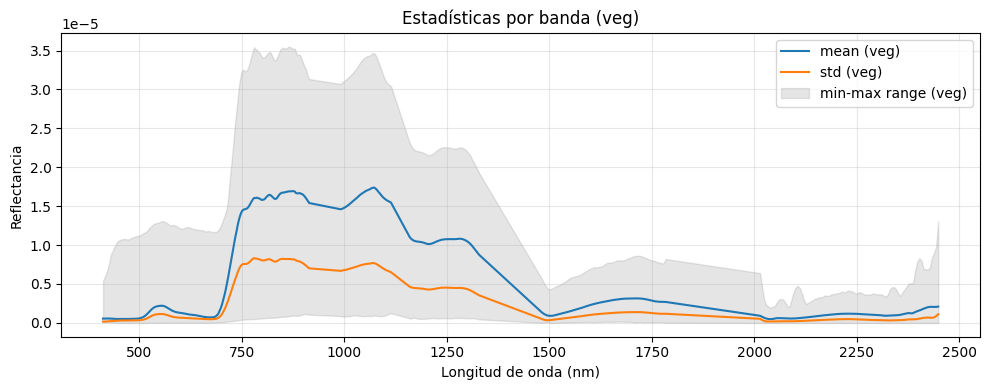

In [19]:
plt.figure(figsize=(10, 4))
plt.plot(wavelengths, band_mean, label='mean (veg)')
plt.plot(wavelengths, band_std, label='std (veg)')
plt.fill_between(wavelengths, band_min, band_max, color='gray', alpha=0.2, label='min-max range (veg)')
plt.ylabel("Reflectancia")
plt.xlabel("Longitud de onda (nm)")
plt.title('Estadísticas por banda (veg)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_FOLDER + "/mean_std.png", dpi=150)

El SNR proxy establece un punto de referencia para evaluar aquellas bandas que podrían presentar problemas de calidad en función de su relación señal/ruido estimada. Cabe la pena mencionar que este SNR proxy solo es una representación para entender el comportamiento y que en ningún caso debe tomarse como un SNR físico del sensor.

Como se observa en su formulación (promedio de reflectancia/ desviación estandar de reflectancia), el proxy busca establecer una relación entre el comportamiento medio de la data comparado contra la variabilidad, que podría deberse a rudio. El objeto de analizar este gráfico es establecer si existen bandas que por su alto contenido de ruido puedan ser difíciles de emplear dentro del próximo modelado. Así pues, podemos sacar las siguientes observaciones a partir del análisis:

1. Entre 400 a 500 nm
Se observa un pico inicial seguido de una caída pronunciada. Este comportamiento indica que, aunque la media de reflectancia en la primera banda es muy baja, la desviación estándar es aún menor, lo que genera un SNR proxy artificialmente alto. Posteriormente, la caída refleja que en la región azul la señal es débil y la variabilidad relativa aumenta, probablemente por efectos de sombras y sensibilidad atmosférica. Estas bandas son menos confiables para modelado directo y conviene usarlas solo en índices robustos o descartarlas.

2. Región roja (650–690 nm)
Aquí se aprecia un valle marcado en el SNR proxy, coherente con la fuerte absorción de clorofila que reduce la media de reflectancia mientras la desviación estándar se mantiene relativamente alta. Esto implica que estas bandas presentan baja estabilidad espectral y podrían introducir ruido en modelos basados en reflectancia directa. Sin embargo, son críticas para índices como NDVI, por lo que se **debe considerar** mantenerlas en índices pero no como variables independientes.

3. Red-edge (705–740 nm)
En esta zona el SNR proxy mejora significativamente, lo que coincide con el incremento abrupto en la media de reflectancia y una desviación estándar moderada. Estas bandas son altamente informativas para evaluar vigor y contenido de clorofila, y además presentan buena estabilidad relativa, por lo que deben priorizarse en el modelado.

4. Meseta NIR (800–1300 nm)
El SNR proxy se mantiene en valores intermedios (≈2.2–2.8), reflejando una media alta y una desviación estándar estable. Esta región es confiable y aporta información sobre estructura foliar y biomasa, por lo que es recomendable conservarla en su totalidad para el modelado.

5. Bordes de ventanas de agua (~1500 nm y ~2000 nm)
Se observan quiebres abruptos en el SNR proxy, asociados a cambios bruscos en la media y la desviación estándar cerca de las zonas de absorción del agua. Aunque las ventanas principales fueron excluidas, los bordes pueden presentar inestabilidad, por lo que se sugiere aplicar márgenes de seguridad (±10–20 nm) al seleccionar bandas.

6. Región SWIR (2000–2400 nm)
El SNR proxy aumenta nuevamente y alcanza valores superiores a 3 en algunas bandas, lo que indica menor variabilidad relativa en vegetación. Estas bandas son útiles para evaluar estrés hídrico y contenido de lignina/celulosa, pero se debe verificar la cobertura válida por banda para evitar sesgos por píxeles escasos.

# 6. Correlación entre bandas contiguas

In [8]:
# Muestreo de píxeles de vegetación para controlar RAM
sample_fraction = 0.02
veg_coords = np.column_stack(np.where(to_numpy(veg_mask)))
n_veg = veg_coords.shape[0]
n_sample = max(5000, int(sample_fraction * n_veg))
idx_sel = RNG.choice(n_veg, size=n_sample, replace=False)
ys, xs = veg_coords[idx_sel, 0], veg_coords[idx_sel, 1]

spec_stack = refl_byx.isel(y=xr.DataArray(ys, dims="points"),
                           x=xr.DataArray(xs, dims="points")).transpose("points","band")
spec_np = spec_stack.astype("float32").values

adj_corr = np.full(refl_byx.sizes["band"]-1, np.nan, dtype="float32")
for k in range(refl_byx.sizes["band"]-1):
    a, b = spec_np[:, k], spec_np[:, k+1]
    m = (~np.isnan(a)) & (~np.isnan(b))
    if m.sum() > 10:
        adj_corr[k] = np.corrcoef(a[m], b[m])[0,1]

corr_df = pd.DataFrame({
    "band_k": np.arange(refl_byx.sizes["band"]-1),
    "wl_k_nm": wavelengths[:-1],
    "wl_k1_nm": wavelengths[1:],
    "adjacent_corr": adj_corr
})
corr_df.to_csv(REPORTS_DIR + "/adjacent_corr.csv", index=False)


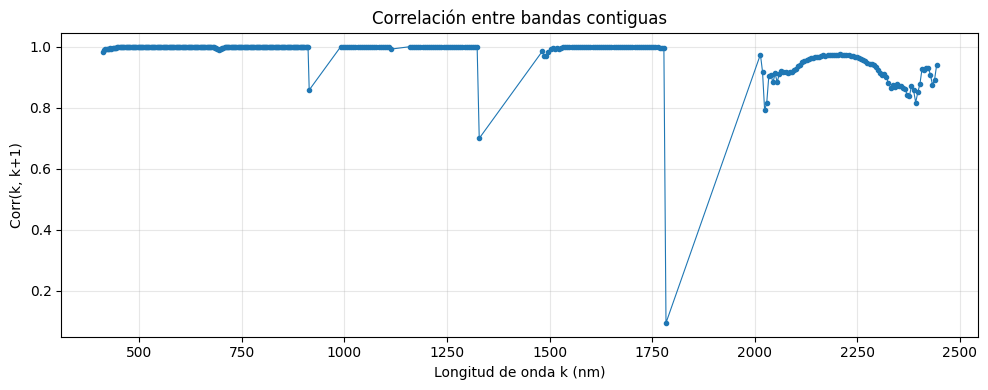

In [9]:
plt.figure(figsize=(10,4))
plt.plot(wavelengths[:-1], adj_corr, lw=0.8, marker='.')
plt.xlabel("Longitud de onda k (nm)"); plt.ylabel("Corr(k, k+1)")
plt.title("Correlación entre bandas contiguas"); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(FIGURES_FOLDER + "/adjacent_corr_curve.png", dpi=150); plt.show()

- VNIR y NIR (≈400–1300 nm): correlación muy alta (≈0.98–1) dentro de segmentos → fuerte redundancia; puedes submuestrear sin perder demasiada información.
- Tramos cercanos a 700–740 nm (red‑edge): pequeños valles locales coherentes con cambios espectrales rápidos → conservar mayor resolución espectral aquí.
- Bordes de 1.4 µm y 1.9 µm: caídas no físicas por saltos (bandas de agua excluidas). Es incorrecto interpretarlas como descorrelación intrínseca; son pares no contiguos en λ.
- SWIR útil (≈2100–2350 nm): correlaciones altas pero algo más variables → informativo para lignina/celulosa/agua; conservar parte, evitando los bordes del gap de 1.9 µm.

Conclusión: para que la métrica sea interpretable, debemos limitar el cálculo a segmentos con Δλ “pequeño y regular” y documentar los gaps.

In [11]:
# --- A) Detectar segmentos espectrales continuos ---

# Paso espectral
dwl = np.diff(wavelengths)  # nm entre bandas vecinas en el Zarr
median_step = float(np.nanmedian(dwl))
# Umbral para considerar GAP (pares no contiguos "reales"):
MAX_STEP = 2.5 * median_step

# Encuentra índices donde hay gap grande
gap_idx = np.where(dwl > MAX_STEP)[0]  # el corte está ENTRE k y k+1
# Construye segmentos [start_idx, end_idx] inclusive sobre índices de banda
segments = []
start = 0
for gi in gap_idx:
    segments.append((start, gi))   # cierre del segmento previo
    start = gi + 1                 # inicio del siguiente
segments.append((start, len(wavelengths)-1))  # último segmento

seg_df = pd.DataFrame([
    {
        "seg_id": s,
        "band_start": a,
        "band_end": b,
        "wl_start_nm": float(wavelengths[a]),
        "wl_end_nm": float(wavelengths[b]),
        "n_bands": int(b-a+1),
        "median_step_nm": float(np.nanmedian(np.diff(wavelengths[a:b+1]))) if (b-a)>=1 else np.nan
    }
    for s, (a,b) in enumerate(segments)
])
seg_df.to_csv(REPORTS_DIR + "/spectral_segments.csv", index=False)
seg_df

,seg_id,band_start,band_end,wl_start_nm,wl_end_nm,n_bands,median_step_nm
0,0,0,173,411.031830,913.989197,174,2.907288
1,1,174,198,990.878235,1113.687622,25,5.117065
2,2,199,232,1159.741089,1328.604004,34,5.117065
3,3,233,292,1482.115723,1784.021973,60,5.117065
4,4,293,378,2014.289551,2449.239502,86,5.116943


Reducción dimensional informada por segmento

- seg0 (411–914, Δλ≈2.9 nm): es claramente sobresampleado (FWHM ~3.8 nm). Muestrear cada ≈15–25 nm sin perder prácticamente información para ML tradicional.
- seg1–seg3 (991–1784, Δλ≈5.1 nm): submuestrear cada ≈20–30 nm es razonable; conserva red‑edge con un poco más de densidad si el SNR lo permite.
- seg4 (2014–2449, Δλ≈5.1 nm): No hacer submuestreo agresivo; usar ≈10–15 nm y evitar ±15–20 nm alrededor del borde de 1.9 µm (ya fuera del segmento, pero sus bordes afectan).

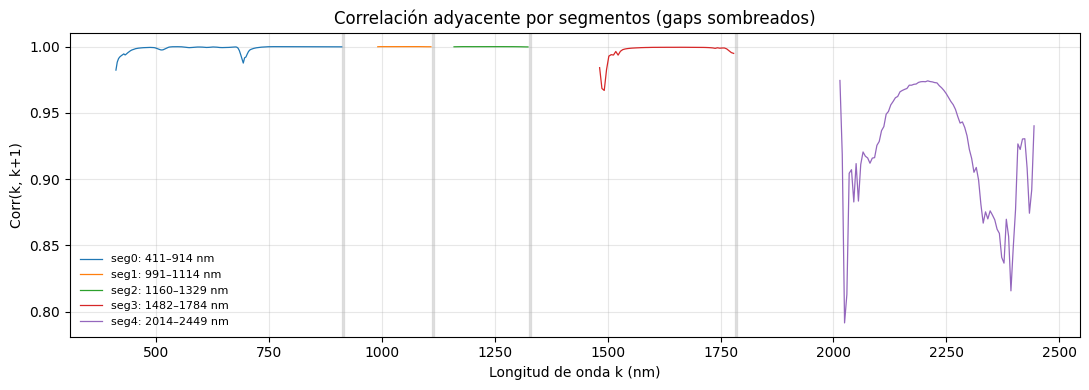

In [12]:
# --- B) Corr(k,k+1) limpia por segmento ---

# Muestreo de vegetación para controlar RAM
veg_coords = np.column_stack(np.where(veg_mask.values))
n_veg = veg_coords.shape[0]
n_sample = max(5000, int(0.02 * n_veg))
idx_sel = RNG.choice(n_veg, size=n_sample, replace=False)
ys, xs = veg_coords[idx_sel, 0], veg_coords[idx_sel, 1]

# Extrae espectros (N, B)
spec_stack = refl_byx.isel(y=xr.DataArray(ys, dims="points"),
                           x=xr.DataArray(xs, dims="points")).transpose("points","band")
X = spec_stack.astype("float32").values

rows = []
for seg_id, (a,b) in enumerate(segments):
    if b <= a: 
        continue
    for k in range(a, b):  # solo dentro del segmento
        a_k, b_k = X[:, k], X[:, k+1]
        m = np.isfinite(a_k) & np.isfinite(b_k)
        n = int(m.sum())
        corr = np.corrcoef(a_k[m], b_k[m])[0,1] if n > 50 else np.nan
        rows.append({
            "seg_id": seg_id,
            "band_k": k,
            "wl_k_nm": float(wavelengths[k]),
            "wl_k1_nm": float(wavelengths[k+1]),
            "delta_nm": float(wavelengths[k+1]-wavelengths[k]),
            "n_valid": n,
            "adjacent_corr": corr
        })

adj_clean = pd.DataFrame(rows)
adj_clean.to_csv(REPORTS_DIR + "/adjacent_corr_by_segment.csv", index=False)

# Plot segmentado
plt.figure(figsize=(11,4))
for seg_id, g in adj_clean.groupby("seg_id"):
    seg_start_wl = seg_df.loc[seg_id, "wl_start_nm"]
    seg_end_wl = seg_df.loc[seg_id, "wl_end_nm"]
    text_segs = f"seg{seg_id}: {seg_start_wl:.0f}–{seg_end_wl:.0f} nm"
    plt.plot(g["wl_k_nm"], g["adjacent_corr"], lw=0.9, label=text_segs)
# sombrear gaps
for gi in gap_idx:
    x = wavelengths[gi]
    plt.axvspan(x-2, x+2, color="gray", alpha=0.2)
plt.xlabel("Longitud de onda k (nm)"); plt.ylabel("Corr(k, k+1)")
plt.title("Correlación adyacente por segmentos (gaps sombreados)")
plt.grid(True, alpha=0.3); plt.legend(ncol=1, fontsize=8, frameon=False)
plt.tight_layout(); plt.savefig(FIGURES_FOLDER + "/adjacent_corr_by_segment.png", dpi=150); plt.show()


## 6.1 Decorrelación por banda en vegetación

¿Qué es la decorrelación espectral?

La decorrelación espectral mide cuán rápido cambia la información espectral entre bandas cercanas en longitud de onda.
En otras palabras, responde a:

¿A qué distancia espectral (Δλ) dos bandas dejan de estar fuertemente correlacionadas?

Esto es útil porque:

En regiones donde la correlación entre bandas adyacentes es muy alta, hay redundancia: muchas bandas aportan información similar.
En cambio, si la correlación cae rápidamente con el aumento de Δλ, hay estructura espectral útil: cambios rápidos en la firma espectral que pueden estar ligados a propiedades bioquímicas o fisiológicas (como contenido de fósforo).

Por eso, estimar la longitud de decorrelación (L90, L95) ayuda a decidir:

- Cuántas bandas conservar en cada segmento.
- Qué tan espaciadas deben estar para evitar redundancia.
- Dónde hay que mantener alta densidad espectral (por ejemplo, en SWIR seg4, como ya identificaste).

In [16]:
# Requiere: segments, wavelengths, X (espectros muestreados N×B) del paso previo
max_lag = 12  # ~ hasta 200 nm en segmentos con paso ~5 nm
decor_rows = []
for seg_id, (a,b) in enumerate(segments):
    if (b - a) < 2: continue
    for lag in range(1, min(max_lag, b-a)+1):
        vals, dls = [], []
        for k in range(a, b-lag+1):
            dlam = wavelengths[k+lag] - wavelengths[k]
            a_k, b_k = X[:, k], X[:, k+lag]
            m = np.isfinite(a_k) & np.isfinite(b_k)
            if m.sum() > 50:
                vals.append(np.corrcoef(a_k[m], b_k[m])[0,1])
                dls.append(dlam)
        if vals:
            decor_rows.append({"seg_id": seg_id,
                               "lag": lag,
                               "median_delta_nm": float(np.median(dls)),
                               "median_corr": float(np.median(vals))})
decor_df = pd.DataFrame(decor_rows)
decor_df.to_csv(REPORTS_DIR + "/corr_vs_dlambda_by_segment.csv", index=False)

def L_at(g, thr):
    g = g.sort_values("median_delta_nm")
    # interpola longitud cuando la correlación mediana cruza el umbral
    return float(np.interp(thr, g["median_corr"][::-1], g["median_delta_nm"][::-1],
                           left=np.nan, right=np.nan))

summary = []
for seg_id, g in decor_df.groupby("seg_id"):
    summary.append({
        "seg_id": seg_id,
        "L95_nm": L_at(g, 0.95),
        "L90_nm": L_at(g, 0.90),
    })
summary_df = pd.DataFrame(summary)
summary_df.to_csv(REPORTS_DIR + f"/decorrelation_length_summary_max_lag_{max_lag}.csv", index=False)
summary_df

,seg_id,L95_nm,L90_nm
0,0,NaN,NaN
1,1,NaN,NaN
2,2,NaN,NaN
3,3,NaN,NaN
4,4,NaN,6.297345


In [17]:
# --- Decorrelación robusta: mayor max_lag + límites cuando no hay cruce ---
import numpy as np
import pandas as pd

# decor_df: median_corr vs median_delta_nm por segmento (ya calculado)
def length_at_threshold(g, thr):
    g = g.dropna().sort_values("median_delta_nm")
    x = g["median_delta_nm"].values
    y = g["median_corr"].values

    if len(x) < 2 or np.all(np.isnan(y)):
        return np.nan, "no-data"

    if np.nanmin(y) > thr:
        # nunca cruza: correlación siempre > thr -> sólo tenemos un L mínimo
        return float(x[-1]), ">=max"   # lower bound: L_thr es mayor que este máximo probado
    if np.nanmax(y) < thr:
        # ya está por debajo desde el inicio -> upper bound
        return float(x[0]), "<=min"

    # cruce por interpolación
    # Asegura monotonicidad aproximada con un suavizado ligero si es necesario
    idx = np.argsort(x); x, y = x[idx], y[idx]
    # buscar el primer cruce descendente
    for i in range(1, len(x)):
        if (y[i-1] >= thr) and (y[i] <= thr):
            # interpolación lineal
            t = (thr - y[i-1]) / (y[i] - y[i-1] + 1e-12)
            return float(x[i-1] + t*(x[i]-x[i-1])), "hit"
    return np.nan, "nan"

summary = []
for seg_id, g in decor_df.groupby("seg_id"):
    L95, s95 = length_at_threshold(g, 0.95)
    L90, s90 = length_at_threshold(g, 0.90)
    summary.append({"seg_id": seg_id, "L95_nm": L95, "L95_status": s95,
                    "L90_nm": L90, "L90_status": s90})
summary_df = pd.DataFrame(summary)
summary_df


,seg_id,L95_nm,L95_status,L90_nm,L90_status
0,0,34.887207,>=max,34.887207,>=max
1,1,61.404663,>=max,61.404663,>=max
2,2,61.404663,>=max,61.404663,>=max
3,3,61.404663,>=max,61.404663,>=max
4,4,5.116943,<=min,6.297345,hit


In [15]:
for thr in [0.99, 0.975, 0.95, 0.90]:
    L, st = length_at_threshold(g, thr)
    print(thr, L, st)
    # guarda el primer umbral que cruce

0.99 5.116943359375 <=min
0.975 5.116943359375 <=min
0.95 5.116943359375 <=min
0.9 6.297345130311823 hit


- L95_nm / L90_nm = mínima separación en nm a la que la correlación mediana entre bandas cae por debajo de 0.95 (o 0.90), dentro de cada segmento continuo (sin gaps).
- ">= max: ni siquiera con el máximo lag evaluado la correlación bajó del umbral ⇒ decorrelación muy lenta (altísima redundancia).
- <=min: ya en el primer lag (paso mínimo de tu segmento) la correlación está por debajo del umbral ⇒ decorrelación muy rápida (baja redundancia).
- hit: el cruce ocurrió dentro del rango evaluado ⇒ puedes usar ese L como espaciamiento objetivo.

Conclusión: seg0–seg3 están sobre‑muestreados en relación con su variabilidad espectral (corr adyacente ~1 incluso a decenas de nm). seg4 sí cambia rápido: a ~6.2 nm ya cae por debajo de 0.9 ⇒ ahí no conviene comprimir fuerte.

**Cabe resaltar que el max_lag se miró en 12 (~60 nm max) para la primera conclusión y también con un máximo de 40 (~200 nm) teniendo únicamente un cambio en el segmento 0 donde se encontró que se podría espaciar a ~40nm (95) o ~70nm (90), sin embargo, dado que espaciar tanto me dejaría con una muestra muy pequeñas de bansas para ese sector, he decidico mantener las conclusiones iniciales y hacer un submuestreo más fino de las bandas, en atención a que el cambio en el contenido de fósforo afecta procesos fisiológicos que se reflejan en el RED-EDGE/NIR como son el contenido de clorofila y la estrcutrua foliar. Así pues, prefiero no desatender esta zona con un submuestreo**

2) N.º efectivo de bandas aproximado (ENB)
ENB ≲ ancho_segmento / L95 (a mayor L95, menos bandas “independientes”).

- seg0: 503 nm / ≥34.9 ≲ ≤14–15
- seg1: 123 nm / ≥61.4 ≲ ≤2
- seg2: 169 nm / ≥61.4 ≲ ≤3
- seg3: 302 nm / ≥61.4 ≲ ≤5
- seg4: 435 nm / ≈6.25 ≳ ≥70 (mucha estructura)

Conclusión: donde la curva tenía “plato” (seg0–3), basta un submuestreo agresivo; en seg4 sí se necesita una malla densa.

3) Recomendación de espaciamiento por segmento (para selección inicial)

Integrar también SNR proxy y cobertura válida (valid_ratio) como filtros.

- seg0 (411–914): usar ≈30–40 nm (más denso 10–15 nm sólo en ~700–740 nm por red‑edge).
- seg1 (991–1114): ≈30–40 nm.
- seg2 (1160–1329): ≈25–35 nm.
- seg3 (1482–1784): ≈30–40 nm; evitar las primeras ~15–20 nm por cercanía al borde de 1.4 µm.
- seg4 (2014–2449): ≈6–10 nm; evitar 2014–2050 nm (borde 1.9 µm). Parea compactar aún más después, pasar a ≈12 nm.

Dos perfiles prácticos

Perfil compacto (≈59–60 antes de filtrar por SNR/valid.):
- seg0: 40 nm (≈12), 
- seg1: 40 nm (≈3), 
- seg2: 35 nm (≈4–5), 
- seg3: 40 nm (≈7), 
- seg4: 12 nm (≈33)

Perfil rico (~80–95 bandas):
- seg0: 25 nm (≈20) con 15 nm en red‑edge (añade 2–3), -
- seg1: 30 nm (≈4), 
- seg2: 25–30 nm (≈6–7), 
- seg3: 30 nm (≈10–11), 
- seg4: 8–10 nm (≈40–50)

# 7. Selección de bandas parametrizada por segmento

In [18]:
# Configuración de logging simple
verbose = True          # activa prints detallados
print_every = 10        # imprime cada N bandas evaluadas por segmento para no saturar

# Lectura de SNR
snr_path = Path(INTERIM_DATA) / "snr_proxy_per_band.csv"
snr = pd.read_csv(snr_path)["snr_proxy"].values  # ojo: .values, no .value

# Cobertura válida en vegetación
print("[INFO] Calculando cobertura válida (valid_ratio) por banda en vegetación...")
valid_ratio = np.zeros(refl_byx.sizes["band"], dtype=float)
for k in range(refl_byx.sizes["band"]):
    print(f"[INFO] Procesando banda ({wavelengths[k]}) {k+1}/{refl_byx.sizes['band']}...")
    arr = refl_byx.isel(band=k).values
    m = np.isfinite(arr) & veg_mask.values
    valid_ratio[k] = m.mean() 
if verbose:
    print(f"[INFO] Cobertura válida (mediana): {np.nanmedian(valid_ratio):.2%}")

valid_ratio = pd.DataFrame({'wavelengths_nm': wavelengths,
                           'valid_ratio': valid_ratio})
valid_ratio.to_csv(INTERIM_DATA + "/valid_ratio_per_band.csv", index=False)

[INFO] Calculando cobertura válida (valid_ratio) por banda en vegetación...
[INFO] Procesando banda (411.0318298339844) 1/379...
[INFO] Procesando banda (413.9390869140625) 2/379...
[INFO] Procesando banda (416.8463439941406) 3/379...
[INFO] Procesando banda (419.7536315917969) 4/379...
[INFO] Procesando banda (422.660888671875) 5/379...
[INFO] Procesando banda (425.5681457519531) 6/379...
[INFO] Procesando banda (428.4754333496094) 7/379...
[INFO] Procesando banda (431.3826904296875) 8/379...
[INFO] Procesando banda (434.2899475097656) 9/379...
[INFO] Procesando banda (437.1972351074219) 10/379...
[INFO] Procesando banda (440.1044921875) 11/379...
[INFO] Procesando banda (443.01177978515625) 12/379...
[INFO] Procesando banda (445.9190368652344) 13/379...


KeyboardInterrupt: 

In [22]:
segments

[(0, np.int64(173)),
 (np.int64(174), np.int64(198)),
 (np.int64(199), np.int64(232)),
 (np.int64(233), np.int64(292)),
 (np.int64(293), 378)]

In [23]:
a, b

(np.int64(293), 378)

In [19]:
valid_ratio = pd.read_csv(INTERIM_DATA + "/valid_ratio_per_band.csv")["valid_ratio"].values
valid_ratio

array([0.48700247, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700255, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700

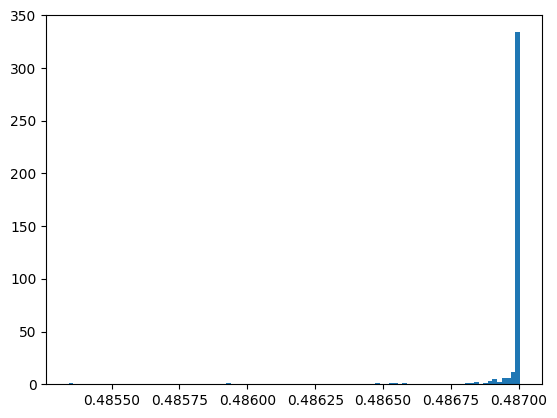

In [24]:
_ = plt.hist(valid_ratio, bins=100)

In [ ]:
def select_bands(
    wavelengths: np.ndarray,          # shape (B,) en nm
    snr: np.ndarray,                  # shape (B,)
    valid_ratio: np.ndarray,          # shape (B,)
    segments: list,                   # [(a,b), ...] índices de banda, INCLUSIVOS
    X: np.ndarray,                    # espectros muestreados (N, B) para corr a pares
    *,
    verbose: bool = True,
    print_every: int = 50,
    # --- Parámetros actualizados con evidencia de decorrelación ---
    L_target_nm: dict = None,         # espaciamiento principal por segmento
    L_fine_windows: dict = None,      # multiescala: seg_id -> [{"wl_min":..., "wl_max":..., "L":...}, ...]
    MARGIN_NEAR_GAPS: dict = None,    # seg_id -> (left_cut_nm, right_cut_nm)
    MAX_PAIR_CORR_SEG: dict = None,   # seg_id -> umbral corr
    SNR_Q_SEG: float = 0.25,          # cuantil de SNR por segmento
    MIN_VALID_BASE: float = 0.45,     # piso de cobertura
    MIN_PAIR_VALID: int = 50,         # mínimo n para calcular corr a pares
    SPACING_FACTOR: dict = None,      # seg_id -> factor para L (p.ej., 0.85)
    # Anchors fisiológicas (nm) y parámetros
    anchors_nm: dict = None,          # nombre índice -> lista de nm canónicas
    anchor_tol_nm: float = 25.0,      # tolerancia en nm para mapear a banda más cercana
    anchor_relax_valid: float = 0.35, # cobertura mínima relajada para anchors
    anchor_relax_snr_q: float = 0.10, # SNR mínimo relajado para anchors: Q10 segmental
    red_edge_bonus_max: float = 0.20  # bonus máx en score dentro de 680–750 (triangular)
):
    """
    Devuelve:
      sel_df: DataFrame con ['seg_id','band_index','wavelength_nm','snr_proxy','valid_ratio_veg']
      reasons_df: DataFrame con razones de descarte/selección y umbrales efectivos
    """
    B = len(wavelengths)
    assert snr.shape[0] == B and valid_ratio.shape[0] == B, "snr/valid_ratio deben tener longitud B"
    assert X.shape[1] == B, "X debe tener forma (N, B)"
    wavelengths = np.asarray(wavelengths).astype(float)

    # ------------------- Parámetros por defecto (si no vienen) -------------------
    if L_target_nm is None:
        # Ajustados a tus nuevos L90/L95:
        # seg0 multiescala (principal ~38 nm y fino en 680–750 nm ~18 nm)
        L_target_nm = {0: 38.0, 1: 50.0, 2: 60.0, 3: 70.0, 4: 7.0}
    if L_fine_windows is None:
        L_fine_windows = {
            # Ventana red-edge con L fino para capturar pendiente de clorofila
            0: [{"wl_min": 680.0, "wl_max": 750.0, "L": 18.0}]
        }
    if MARGIN_NEAR_GAPS is None:
        # Márgenes asimétricos que ya usabas
        MARGIN_NEAR_GAPS = {3: (15.0, 10.0), 4: (36.0, 20.0)}
    if MAX_PAIR_CORR_SEG is None:
        # Endurecido levemente en seg0–3 dado el sobremuestreo extremo observado
        MAX_PAIR_CORR_SEG = {0: 0.9990, 1: 0.9990, 2: 0.9990, 3: 0.9990, 4: 0.98}
    if SPACING_FACTOR is None:
        # Más estricto en seg1–3; estándar en seg0 y fino en seg4
        SPACING_FACTOR = {0: 0.85, 1: 0.90, 2: 0.90, 3: 0.90, 4: 0.85}
    if anchors_nm is None:
        anchors_nm = {
            "PRI":    [531.0, 570.0],
            "PSRI":   [500.0, 678.0, 750.0],
            "NDRE":   [705.0, 750.0],      # a veces 780–782 nm para NIR
            "CIgreen":[550.0, 782.0]
        }

    # ------------------- Utilidades internas -------------------
    def L_local(seg_id: int, wl: float) -> float:
        """Devuelve el L a usar en esa λ considerando ventanas finas."""
        L = L_target_nm.get(seg_id, 30.0)
        for w in L_fine_windows.get(seg_id, []):
            if w["wl_min"] <= wl <= w["wl_max"]:
                return float(w["L"])
        return float(L)

    def red_edge_bonus(wl: float) -> float:
        """Bonus triangular en 680–750 nm, pico en ~710–720 nm."""
        a, b = 680.0, 750.0
        if wl < a or wl > b:
            return 0.0
        # Triángulo centrado en 715 nm
        center = 715.0
        half = (b - a) / 2.0  # 35 nm
        # distancia normalizada 0..1
        d = abs(wl - center) / half
        return float(max(0.0, (1 - d)) * red_edge_bonus_max)

    def nearest_band(target_nm: float, idx_range: np.ndarray) -> int | None:
        """Devuelve índice de banda más cercana al target dentro de idx_range, o None si vacío."""
        if idx_range.size == 0:
            return None
        idx = idx_range[np.argmin(np.abs(wavelengths[idx_range] - target_nm))]
        return int(idx)

    # ------------------- Salidas -------------------
    selected_rows = []
    reasons_rows  = []

    if verbose:
        print("[INFO] Parámetros:")
        print(f"       L_target_nm: {L_target_nm}")
        print(f"       L_fine_windows: {L_fine_windows}")
        print(f"       MARGIN_NEAR_GAPS: {MARGIN_NEAR_GAPS}")
        print(f"       MAX_PAIR_CORR_SEG: {MAX_PAIR_CORR_SEG}")
        print(f"       SPACING_FACTOR: {SPACING_FACTOR}")
        print(f"       SNR_Q_SEG: Q{int(SNR_Q_SEG*100)} segmental; MIN_VALID_BASE={MIN_VALID_BASE}; MIN_PAIR_VALID={MIN_PAIR_VALID}")
        print(f"       anchors_nm: {anchors_nm} | tol={anchor_tol_nm} nm | relax valid={anchor_relax_valid}, snr Q={anchor_relax_snr_q}")

    # ------------------- Iteración por segmentos -------------------
    for seg_id, (seg_a, seg_b) in enumerate(segments):
        # Asegurar inclusividad
        a = int(seg_a); b = int(seg_b)
        if b < a:
            continue

        wl_start = float(wavelengths[a])
        wl_end   = float(wavelengths[b])
        L_main   = float(L_target_nm.get(seg_id, 30.0))
        left_cut, right_cut = MARGIN_NEAR_GAPS.get(seg_id, (0.0, 0.0))
        spacing_factor = float(SPACING_FACTOR.get(seg_id, 0.85))
        MAX_PAIR_CORR  = float(MAX_PAIR_CORR_SEG.get(seg_id, 0.99))

        seg_idx = np.arange(a, b + 1)
        seg_wl  = wavelengths[seg_idx]
        seg_snr = snr[seg_idx]
        seg_valid = valid_ratio[seg_idx]

        # Umbrales adaptativos por segmento
        snr_q_seg  = np.nanquantile(seg_snr, SNR_Q_SEG)
        snr_q10_seg = np.nanquantile(seg_snr, 0.10)  # para anchors relajados
        valid_q25_seg = np.nanquantile(seg_valid, 0.25)
        MIN_VALID_SEG = max(MIN_VALID_BASE, float(valid_q25_seg))

        if verbose:
            print(f"\n[SEG {seg_id}] λ≈{wl_start:.1f}–{wl_end:.1f} nm | bandas={b-a+1} | L_main={L_main:.1f} nm "
                  f"| margins=({left_cut:.1f},{right_cut:.1f}) nm | spacing≥{spacing_factor:.2f}·L | "
                  f"SNR≥Q{int(SNR_Q_SEG*100)}={snr_q_seg:.3f} | valid≥{MIN_VALID_SEG:.0%}")

        # 1) Filtro duro: márgenes, valid_ratio, SNR (segmentales)
        cand = []
        for i in seg_idx:
            wl_i = float(wavelengths[i])
            # márgenes cerca de bordes del segmento
            if (wl_i - wl_start) < left_cut:
                reasons_rows.append({"seg_id": seg_id, "band_index": i, "reason": "near_left_gap",
                                     "wl_nm": wl_i, "L": L_main, "min_valid": MIN_VALID_SEG, "snr_q": snr_q_seg})
                continue
            if (wl_end - wl_i) < right_cut:
                reasons_rows.append({"seg_id": seg_id, "band_index": i, "reason": "near_right_gap",
                                     "wl_nm": wl_i, "L": L_main, "min_valid": MIN_VALID_SEG, "snr_q": snr_q_seg})
                continue
            # cobertura / SNR
            if (not np.isfinite(valid_ratio[i])) or (valid_ratio[i] < MIN_VALID_SEG):
                reasons_rows.append({"seg_id": seg_id, "band_index": i, "reason": "low_valid",
                                     "wl_nm": wl_i, "valid": float(valid_ratio[i]) if np.isfinite(valid_ratio[i]) else np.nan,
                                     "min_valid": MIN_VALID_SEG})
                continue
            if (not np.isfinite(snr[i])) or (snr[i] < snr_q_seg):
                reasons_rows.append({"seg_id": seg_id, "band_index": i, "reason": "low_snr",
                                     "wl_nm": wl_i, "snr": float(snr[i]) if np.isfinite(snr[i]) else np.nan,
                                     "snr_q": snr_q_seg})
                continue
            cand.append(i)

        if verbose:
            print(f"[SEG {seg_id}] Candidatas tras filtros: {len(cand)} / {b-a+1} "
                  f"(≥{MIN_VALID_SEG:.0%} válidos & SNR≥Q{int(SNR_Q_SEG*100)})")

        if len(cand) == 0:
            if verbose:
                print(f"[SEG {seg_id}] ⚠️  Sin candidatas, se omite segmento.")
            continue

        # 2) Score por SNR + valid_ratio + bonus red-edge (dentro del segmento)
        def score(i: int) -> float:
            s = snr[i]
            v = valid_ratio[i]
            wl_i = float(wavelengths[i])
            # z-scores segmentales simples (evitar NaN)
            s_norm = (s - np.nanmean(seg_snr)) / (np.nanstd(seg_snr) + 1e-6)
            v_norm = (v - np.nanmean(seg_valid)) / (np.nanstd(seg_valid) + 1e-6)
            return (s_norm + 0.5 * v_norm) + red_edge_bonus(wl_i)

        order = sorted(cand, key=score, reverse=True)
        if verbose:
            preview = [(int(i), float(wavelengths[i]), float(snr[i]),
                        float(valid_ratio[i])) for i in order[:min(5, len(order))]]
            print(f"[SEG {seg_id}] Top-5 por score (idx, nm, SNR, valid): {preview}")

        # 3) Pre-selección de anchors (forzadas con filtros relajados)
        keep = []
        # idx válidos del segmento para anchors
        seg_idx_arr = np.array(seg_idx, dtype=int)

        # construir lista de nm a anclar que caen en este segmento (por límites espectrales)
        anchors_targets = []
        for name, nm_list in anchors_nm.items():
            for t in nm_list:
                if wl_start - anchor_tol_nm <= t <= wl_end + anchor_tol_nm:
                    anchors_targets.append((name, float(t)))

        for name, target_nm in anchors_targets:
            # banda más cercana dentro del segmento
            bi = nearest_band(target_nm, seg_idx_arr)
            if bi is None:
                continue
            wl_i = float(wavelengths[bi])
            # tolerancia
            if abs(wl_i - target_nm) > anchor_tol_nm:
                continue
            # chequear márgenes
            if (wl_i - wl_start) < left_cut or (wl_end - wl_i) < right_cut:
                continue
            # chequear filtros relajados
            v_i = valid_ratio[bi]; s_i = snr[bi]
            if not np.isfinite(v_i) or v_i < anchor_relax_valid:
                continue
            if not np.isfinite(s_i) or s_i < max(snr_q10_seg, 0.0):
                continue
            # backstop de correlación vs vecindad existente
            L_i = L_local(seg_id, wl_i)
            # Vecindad: |Δλ| < 0.5·L_i
            neighbors = [j for j in keep if abs(float(wavelengths[j]) - wl_i) < 0.5 * L_i]
            ok = True
            for j in neighbors:
                a_i, a_j = X[:, bi], X[:, j]
                m = np.isfinite(a_i) & np.isfinite(a_j)
                n = int(m.sum())
                if n > MIN_PAIR_VALID:
                    c = np.corrcoef(a_i[m], a_j[m])[0, 1]
                    if c > MAX_PAIR_CORR:
                        ok = False
                        reasons_rows.append({"seg_id": seg_id, "band_index": bi,
                                             "reason": f"anchor_pair_corr>{MAX_PAIR_CORR}",
                                             "wl_nm": wl_i, "n_valid": n, "corr": float(c)})
                        break
            if ok and bi not in keep:
                keep.append(bi)
                reasons_rows.append({"seg_id": seg_id, "band_index": bi, "reason": "forced_anchor",
                                     "anchor_nm": target_nm, "wl_nm": wl_i, "snr": float(s_i),
                                     "valid": float(v_i)})

        # 4) Selección greedy con espaciamiento y backstop de correlación en vecindad
        evaluated = 0
        for i in order:
            if i in keep:
                continue
            wl_i = float(wavelengths[i])
            L_i = L_local(seg_id, wl_i)
            # Espaciamiento: min distancia en λ a lo ya seleccionado
            if keep:
                min_d = min(abs(wl_i - float(wavelengths[j])) for j in keep)
                if min_d < spacing_factor * L_i:
                    reasons_rows.append({"seg_id": seg_id, "band_index": i, "reason": "spacing",
                                         "wl_nm": wl_i, "min_dist_nm": float(min_d),
                                         "required_nm": float(spacing_factor * L_i)})
                    evaluated += 1
                    if verbose and (evaluated % print_every == 0):
                        print(f"[SEG {seg_id}] Evaluadas {evaluated}/{len(order)}... descarta por spacing: "
                              f"idx {i}, λ={wl_i:.1f} nm (min_d={min_d:.1f} < {spacing_factor*L_i:.1f})")
                    continue
            # Backstop de correlación SOLO con vecindad
            neighbors = [j for j in keep if abs(float(wavelengths[j]) - wl_i) < 0.5 * L_i]
            ok = True
            for j in neighbors:
                a_i, a_j = X[:, i], X[:, j]
                m = np.isfinite(a_i) & np.isfinite(a_j)
                n = int(m.sum())
                if n > MIN_PAIR_VALID:
                    c = np.corrcoef(a_i[m], a_j[m])[0, 1]
                    if c > MAX_PAIR_CORR:
                        ok = False
                        reasons_rows.append({"seg_id": seg_id, "band_index": i,
                                             "reason": f"pair_corr>{MAX_PAIR_CORR}",
                                             "wl_nm": wl_i, "neighbor_idx": int(j),
                                             "neighbor_wl_nm": float(wavelengths[j]),
                                             "n_valid": n, "corr": float(c)})
                        break
                else:
                    reasons_rows.append({"seg_id": seg_id, "band_index": i,
                                         "reason": "pair_corr_skipped_n<=MIN",
                                         "wl_nm": wl_i, "neighbor_idx": int(j),
                                         "neighbor_wl_nm": float(wavelengths[j]),
                                         "n_valid": n})
            if ok:
                keep.append(i)
                if verbose:
                    print(f"[SEG {seg_id}] ✅ Seleccionada: idx {i} | λ={wl_i:.1f} nm | "
                          f"SNR={float(snr[i]):.3f} | valid={float(valid_ratio[i]):.2%} | sel_seg={len(keep)}")

            evaluated += 1
            if verbose and (evaluated % print_every == 0):
                print(f"[SEG {seg_id}] Progreso: {evaluated}/{len(order)} evaluadas, {len(keep)} elegidas.")

        # 5) Persistir selección del segmento
        keep_sorted = sorted(set(keep))
        for i in keep_sorted:
            selected_rows.append({
                "seg_id": seg_id,
                "band_index": int(i),
                "wavelength_nm": float(wavelengths[i]),
                "snr_proxy": float(snr[i]) if np.isfinite(snr[i]) else np.nan,
                "valid_ratio_veg": float(valid_ratio[i]) if np.isfinite(valid_ratio[i]) else np.nan
            })

        if verbose:
            if keep_sorted:
                print(f"[SEG {seg_id}] ✔️  Seleccionadas: {len(keep_sorted)} "
                      f"(λ: {float(wavelengths[keep_sorted[0]]):.1f}–{float(wavelengths[keep_sorted[-1]]):.1f} nm)")
            else:
                print(f"[SEG {seg_id}] ⚠️  No se seleccionaron bandas.")

        # 6) Trazabilidad de umbrales efectivos (como reasons 'params')
        reasons_rows.append({"seg_id": seg_id, "band_index": -1, "reason": "params",
                             "L_main": L_main, "spacing_factor": spacing_factor,
                             "left_cut": left_cut, "right_cut": right_cut,
                             "snr_q_seg": float(snr_q_seg), "valid_min_seg": float(MIN_VALID_SEG),
                             "max_pair_corr": MAX_PAIR_CORR})

    sel_df = pd.DataFrame(selected_rows).sort_values(["seg_id", "wavelength_nm"]).reset_index(drop=True)
    reasons_df = pd.DataFrame(reasons_rows)
    return sel_df, reasons_df

sel_df, reasons_df = select_bands(wavelengths, snr, valid_ratio, segments, X, verbose=True)

[INFO] Parámetros:
       L_target_nm: {0: 38.0, 1: 50.0, 2: 60.0, 3: 70.0, 4: 7.0}
       L_fine_windows: {0: [{'wl_min': 680.0, 'wl_max': 750.0, 'L': 18.0}]}
       MARGIN_NEAR_GAPS: {3: (15.0, 10.0), 4: (36.0, 20.0)}
       MAX_PAIR_CORR_SEG: {0: 0.999, 1: 0.999, 2: 0.999, 3: 0.999, 4: 0.98}
       SPACING_FACTOR: {0: 0.85, 1: 0.9, 2: 0.9, 3: 0.9, 4: 0.85}
       SNR_Q_SEG: Q25 segmental; MIN_VALID_BASE=0.45; MIN_PAIR_VALID=50
       anchors_nm: {'PRI': [531.0, 570.0], 'PSRI': [500.0, 678.0, 750.0], 'NDRE': [705.0, 750.0], 'CIgreen': [550.0, 782.0]} | tol=25.0 nm | relax valid=0.35, snr Q=0.1

[SEG 0] λ≈411.0–914.0 nm | bandas=174 | L_main=38.0 nm | margins=(0.0,0.0) nm | spacing≥0.85·L | SNR≥Q25=1.810 | valid≥49%
[SEG 0] Candidatas tras filtros: 129 / 174 (≥49% válidos & SNR≥Q25)
[SEG 0] Top-5 por score (idx, nm, SNR, valid): [(1, 413.9390869140625, 3.304166, 0.487002625748227), (2, 416.8463439941406, 3.2435493, 0.487002625748227), (3, 419.7536315917969, 3.1265423, 0.48700262574822

Con esta configuración, el proceso ha seleccionado pocas bandas para los seg1 a seg3 por lo cual modifico para probar un ajuste menos estricto en esos segmentos.

In [60]:
reasons_df.query("seg_id in [1,2,3]").reason.value_counts()

reason
spacing           71
low_snr           30
params             3
near_left_gap      3
low_valid          3
near_right_gap     2
Name: count, dtype: int64

In [ ]:
params_override = dict(
    # 1) Espaciamiento: bajar L_target y factor en seg1–seg3
    L_target_nm = {0: 38.0, 1: 35.0, 2: 40.0, 3: 50.0, 4: 7.0},
    SPACING_FACTOR = {0: 0.85, 1: 0.7, 2: 0.7, 3: 0.7, 4: 0.85},

    # 2) SNR por segmento: relajar
    SNR_Q_SEG = 0.15, 

    # 3) Mantener márgenes y cobertura (opcionales de ajuste fino)
    MIN_VALID_BASE = 0.45,  
    MARGIN_NEAR_GAPS = {3: (15.0, 10.0), 4: (36.0, 20.0)}
)


anchors_nm = {
    "PRI":    [531.0, 570.0],
    "PSRI":   [500.0, 678.0, 750.0],
    "NDRE":   [705.0, 750.0],
    "CIgreen":[550.0, 782.0]
}


sel_df, reasons_df = select_bands(
    wavelengths, snr, valid_ratio, segments, X,
    L_target_nm=params_override["L_target_nm"],
    SPACING_FACTOR=params_override["SPACING_FACTOR"],
    SNR_Q_SEG=params_override["SNR_Q_SEG"],
    MIN_VALID_BASE=params_override["MIN_VALID_BASE"],
    MARGIN_NEAR_GAPS=params_override["MARGIN_NEAR_GAPS"],
    anchors_nm=anchors_nm,
    anchor_tol_nm=25.0,
    anchor_relax_valid=0.35,
    anchor_relax_snr_q=0.10,
    verbose=True
)

[INFO] Parámetros:
       L_target_nm: {0: 38.0, 1: 35.0, 2: 40.0, 3: 50.0, 4: 7.0}
       L_fine_windows: {0: [{'wl_min': 680.0, 'wl_max': 750.0, 'L': 18.0}]}
       MARGIN_NEAR_GAPS: {3: (15.0, 10.0), 4: (36.0, 20.0)}
       MAX_PAIR_CORR_SEG: {0: 0.999, 1: 0.999, 2: 0.999, 3: 0.999, 4: 0.98}
       SPACING_FACTOR: {0: 0.85, 1: 0.7, 2: 0.7, 3: 0.7, 4: 0.85}
       SNR_Q_SEG: Q15 segmental; MIN_VALID_BASE=0.45; MIN_PAIR_VALID=50
       anchors_nm: {'PRI': [531.0, 570.0], 'PSRI': [500.0, 678.0, 750.0], 'NDRE': [705.0, 750.0], 'CIgreen': [550.0, 782.0]} | tol=25.0 nm | relax valid=0.35, snr Q=0.1

[SEG 0] λ≈411.0–914.0 nm | bandas=174 | L_main=38.0 nm | margins=(0.0,0.0) nm | spacing≥0.85·L | SNR≥Q15=1.655 | valid≥49%
[SEG 0] Candidatas tras filtros: 147 / 174 (≥49% válidos & SNR≥Q15)
[SEG 0] Top-5 por score (idx, nm, SNR, valid): [(1, 413.9390869140625, 3.304166, 0.487002625748227), (2, 416.8463439941406, 3.2435493, 0.487002625748227), (3, 419.7536315917969, 3.1265423, 0.48700262574822

In [56]:
reasons_df.query("seg_id in [1,2,3]").reason.value_counts()

reason
spacing           74
low_snr           18
params             3
near_left_gap      3
low_valid          3
near_right_gap     2
Name: count, dtype: int64

In [57]:
sel_df 

,seg_id,band_index,wavelength_nm,snr_proxy,valid_ratio_veg
0,0,1,413.939087,3.304166,0.487003
1,0,13,448.826294,1.699654,0.487003
2,0,31,501.157135,1.718806,0.487003
3,0,41,530.229797,1.925885,0.487003
4,0,48,550.580688,1.919247,0.487003
5,0,55,570.931580,1.952280,0.487003
6,0,67,605.818787,1.910738,0.487003
7,0,79,640.705994,1.738496,0.487003
8,0,101,704.665894,2.085348,0.487003
9,0,107,722.109497,2.009879,0.487003


In [55]:
reasons_df[reasons_df["wl_nm"].between(660.0, 690.0)]

,seg_id,band_index,reason,wl_nm,valid,min_valid,snr,snr_q,anchor_nm,n_valid,...,min_dist_nm,required_nm,L_main,spacing_factor,left_cut,right_cut,snr_q_seg,valid_min_seg,max_pair_corr,L
17,0,86,low_snr,661.056885,NaN,NaN,1.543186,1.655172,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,0,87,low_snr,663.964172,NaN,NaN,1.522545,1.655172,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,0,88,low_snr,666.871399,NaN,NaN,1.506539,1.655172,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,0,89,low_snr,669.778687,NaN,NaN,1.495362,1.655172,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21,0,90,low_snr,672.685974,NaN,NaN,1.490856,1.655172,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,0,91,low_snr,675.593201,NaN,NaN,1.489234,1.655172,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23,0,92,low_snr,678.500488,NaN,NaN,1.496125,1.655172,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,0,93,low_snr,681.407776,NaN,NaN,1.512933,1.655172,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,0,94,low_snr,684.315002,NaN,NaN,1.559314,1.655172,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,0,95,low_snr,687.222290,NaN,NaN,1.645101,1.655172,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [58]:
sel_df.to_csv(INTERIM_DATA + "/bands_selected_by_segment.csv", index=False)
reasons_df.to_csv(INTERIM_DATA + "/bands_selection_reasons.csv", index=False)

## Selección de bandas espectrales

Para reducir la redundancia espectral y preservar la información relevante para la detección de deficiencia de fósforo en frijol, se implementó un procedimiento de selección de bandas basado en análisis previos de correlación adyacente, longitud de decorrelación (L90/L95) y relación señal/ruido (SNR). Estos análisis mostraron que los segmentos VNIR–NIR–SWIR1 presentan sobremuestreo extremo (correlaciones >0.99 incluso con separaciones >120 nm), mientras que el segmento SWIR2 exhibe decorrelación rápida (L90≈6.3 nm), lo que justifica mantener alta densidad espectral en esta región.
Con base en estos hallazgos, se definieron los siguientes criterios:

- Espaciamiento objetivo por segmento (L_target): seg0=38 nm, seg1=35 nm, seg2=40 nm, seg3=50 nm, seg4=7 nm.
- Espaciamiento mínimo efectivo: ≥ SPACING_FACTOR·L_local(λ) (seg0=0.85; seg1–3=0.70; seg4=0.85), permitiendo mayor densidad en seg1–3 para incrementar muestreo.
- Filtros duros: cobertura mínima en vegetación (valid_ratio ≥ max(0.45, Q25_seg)) y SNR ≥ Q15 segmental.
- Márgenes asimétricos contra los bordes de las ventanas de absorción del agua (± 1.4 y 1.9 µm).
- Backstop de colinealidad: descartar candidatos con correlación a pares > 0.999 (seg0–3) o > 0.98 (seg4), evaluada solo en vecindad espectral (|Δλ| < 0.5·L_local).
- Anclas fisiológicas: garantizar bandas cercanas a 531/550/570 nm (PRI, CIgreen), 705/750/782 nm (NDRE), y 500 nm (PSRI), priorizando su inclusión con filtros relajados cuando fue necesario.

La selección final resultó en 58 bandas distribuidas por segmento:

- VNIR/red-edge (seg0): 15 bandas (413–914 nm), incluyendo anclas para PRI, CIgreen y NDRE.
- NIR (seg1): 5 bandas (1011–1113 nm), equiespaciadas (~24–26 nm).
- SWIR1 (seg2): 6 bandas (1159–1328 nm), espaciadas ~30–35 nm.
- SWIR1b (seg3): 8 bandas (1497–1773 nm), respetando márgenes frente al gap de 1.9 µm.
- SWIR2 (seg4): 24 bandas (2060–2428 nm), con alta densidad (~6–10 nm) acorde con su rápida decorrelación y relevancia bioquímica (agua, estructura celular).

Esta configuración reduce el número total de variables respecto al cubo original (379 bandas), minimiza redundancia en segmentos sobremuestreados y preserva dominios espectrales críticos para el objetivo del estudio. Además, garantiza la posibilidad de calcular índices fisiológicos relevantes (PRI, NDRE, CIgreen) y mantiene la densidad necesaria en SWIR2 para capturar variaciones sutiles asociadas a la composición bioquímica. Todos los parámetros utilizados (espaciamientos, factores, cuantiles, márgenes y umbrales) fueron registrados junto con las salidas de selección, asegurando reproducibilidad del proceso.

In [85]:
# --- PCA (3 componentes) con modos 'all' y 'selected' ---
# Mantiene tu MIN_VALID_RATIO_PER_BAND basado en valid_ratio GLOBAL (no se recalcula aquí)

import os, json
import numpy as np
import pandas as pd
import xarray as xr
from pathlib import Path
from sklearn.decomposition import IncrementalPCA

# ========= Parámetros =========
RNG = np.random.default_rng(42)
N_COMPONENTS = 3
SAMPLE_SIZE = 200_000            # número máximo de píxeles muestreados
BATCH_SIZE = 2000                # tamaño de lote IncrementalPCA
CHUNKS_YX = 512                  # chunk espacial para PCs
WATER_EXCLUSIONS = [(1340.0, 1440.0), (1800.0, 1950.0)]  # nm
MIN_VALID_RATIO_PER_BAND = 0.45  # <-- Mantienes este umbral global

# Rutas (ajusta si difieren en tu repo; se convierten a Path robustamente)
INTERIM_DIR       = Path(str(INTERIM_DATA))
REPORTS_DIR_PATH  = Path(str(REPORTS_DIR))
OUT_ZARR_DIR      = Path("../data/processed/zarr");   OUT_ZARR_DIR.mkdir(parents=True, exist_ok=True)
OUT_TIF_DIR       = Path("../data/processed/geotiff"); OUT_TIF_DIR.mkdir(parents=True, exist_ok=True)

EXPORT_GEOTIFF = False  # True si quieres GeoTIFF además de Zarr
crs = None              # p.ej., "EPSG:32618" si EXPORT_GEOTIFF=True
transform = None        # tu Affine transform si EXPORT_GEOTIFF=True

# ========= Utilidades =========
def bands_excluding_windows(wavelengths_nm: np.ndarray, windows_nm):
    """Índices de bandas cuyo λ NO cae en ninguna ventana de exclusión."""
    wl = np.asarray(wavelengths_nm, dtype=float)
    mask = np.ones_like(wl, dtype=bool)
    for a, b in windows_nm:
        mask &= ~((wl >= a) & (wl <= b))
    return np.where(mask)[0]

def intersect_sorted(a, b):
    """Intersección ordenada de arrays de índices."""
    return np.intersect1d(np.asarray(a, int), np.asarray(b, int), assume_unique=False)

def sample_veg_coords(veg_mask: xr.DataArray, mask_nodata: xr.DataArray, rng, kmax: int):
    """Devuelve (ys, xs, n_total_veg_valid) muestreados en vegetación válida (veg_mask ∧ mask_nodata==0)."""
    mask_valid = (veg_mask.data.astype(bool)) & (mask_nodata.data == 0)
    coords = np.column_stack(np.where(mask_valid))
    n = coords.shape[0]
    if n == 0:
        raise RuntimeError("No hay píxeles válidos en vegetación (verifica veg_mask y mask_nodata).")
    k = int(min(kmax, n))
    sel = rng.choice(n, size=k, replace=False)
    ys, xs = coords[sel, 0], coords[sel, 1]
    return ys.astype(int), xs.astype(int), n

def fit_pca_on_sample(refl_da: xr.DataArray, bands_idx: np.ndarray, ys, xs,
                      n_components=3, batch_size=2000):
    """
    Extrae matriz (N x B_used) sin NaNs por fila, centra por banda y ajusta IncrementalPCA.
    Devuelve (ipca, band_mean_all, used_rows).
    """
    # Extraer (N x B_used)
    spec = refl_da.isel(band=xr.DataArray(bands_idx, dims="band"),
                        y=xr.DataArray(ys, dims="points"),
                        x=xr.DataArray(xs, dims="points")).transpose("points","band")
    X = spec.astype("float32").values

    # Filtra filas completas sin NaN (crítico para IncrementalPCA)
    row_ok = np.all(np.isfinite(X), axis=1)
    X = X[row_ok]
    if X.shape[0] == 0:
        raise RuntimeError("Muestra para PCA quedó vacía tras filtrar NaNs. Baja MIN_VALID_RATIO_PER_BAND o revisa máscaras.")

    # Centro por banda (no escalo)
    band_mean_all = X.mean(axis=0, dtype="float64")
    Xc = X - band_mean_all

    ipca = IncrementalPCA(n_components=n_components, batch_size=batch_size)
    ipca.fit(Xc)

    return ipca, band_mean_all, int(X.shape[0])

def project_pcs(refl_da: xr.DataArray, bands_idx: np.ndarray, band_mean_all: np.ndarray, ipca, chunks_yx=512):
    """Proyecta PCs sobre toda la escena usando las mismas bandas y media por banda."""
    cube_sub = refl_da.isel(band=xr.DataArray(bands_idx, dims="band"))
    cube_c = cube_sub - xr.DataArray(band_mean_all, dims=["band"])
    comps = ipca.components_.astype("float32")  # (pc, band_used)

    pcs = []
    for i in range(comps.shape[0]):
        w = xr.DataArray(comps[i], dims=["band"])
        pcs.append((cube_c * w).sum(dim="band"))
    pcs_da = xr.concat(pcs, dim="pc").transpose("pc","y","x").astype("float32")
    pcs_da = pcs_da.assign_coords(pc=np.arange(1, comps.shape[0]+1)).rename("PCA")
    pcs_da = pcs_da.chunk({"pc": -1, "y": chunks_yx, "x": chunks_yx})
    return pcs_da

def export_pcs_geotiff(pcs_da: xr.DataArray, out_path: Path, crs, transform):
    import rasterio
    pcs_np = np.stack([pcs_da.isel(pc=i).values for i in range(pcs_da.sizes["pc"])], axis=0)
    profile = {
        "driver": "GTiff", "height": pcs_np.shape[1], "width": pcs_np.shape[2],
        "count": pcs_np.shape[0], "dtype": "float32",
        "crs": crs, "transform": transform,
        "tiled": True, "blockxsize": 256, "blockysize": 256,
        "compress": "deflate", "predictor": 2, "bigtiff": "IF_SAFER"
    }
    with rasterio.open(out_path, "w", **profile) as dst:
        for i in range(pcs_np.shape[0]):
            dst.write(pcs_np[i], i+1)

# ========= Runner =========
def run_pca(
    mode="selected",
    bands_selected_csv=INTERIM_DIR / "bands_selected_by_segment.csv",
    water_exclusions=WATER_EXCLUSIONS,
    min_valid_ratio_per_band=MIN_VALID_RATIO_PER_BAND,
    export_geotiff=EXPORT_GEOTIFF,
    out_prefix="pca_components",
    valid_ratio_array=None  # <-- pasa tu valid_ratio GLOBAL ya calculado (np.ndarray shape (B,))
):
    """
    mode:
      - 'all'      → usa todas las bandas salvo exclusiones por agua
      - 'selected' → usa bandas seleccionadas intersectadas con exclusiones por agua

    min_valid_ratio_per_band:
      - Se aplica sobre el 'valid_ratio' GLOBAL que pasas en 'valid_ratio_array';
        si None o <=0, no filtra bandas por cobertura.
    """
    # 1) Construir set de bandas
    bands_all = np.arange(refl_byx.sizes["band"])
    bands_no_water = bands_excluding_windows(wavelengths, water_exclusions)

    if mode == "selected":
        if not Path(bands_selected_csv).exists():
            raise ValueError("No se encontró CSV de bandas seleccionadas para mode='selected'.")
        sel = pd.read_csv(bands_selected_csv)
        if "band_index" not in sel.columns:
            raise ValueError("El CSV de seleccionadas debe tener columna 'band_index'.")
        bands_sel = np.asarray(sel["band_index"].values, dtype=int)
        bands_used = intersect_sorted(bands_sel, bands_no_water)
    elif mode == "all":
        bands_used = np.asarray(bands_no_water, dtype=int)
    else:
        raise ValueError("mode debe ser 'selected' o 'all'.")

    # 2) Filtro por cobertura GLOBAL si se solicita (no se recalcula valid_ratio)
    if (valid_ratio_array is not None) and (min_valid_ratio_per_band > 0.0):
        vr = np.asarray(valid_ratio_array, dtype=float)
        keep = [int(b) for b in bands_used if (np.isfinite(vr[b]) and vr[b] >= min_valid_ratio_per_band)]
        bands_used = np.array(keep, dtype=int)

    if bands_used.size == 0:
        raise RuntimeError("No quedan bandas para PCA tras aplicar exclusiones/filtros (revisa parámetros).")

    # 3) Muestreo de vegetación válida
    ys, xs, n_veg = sample_veg_coords(veg_mask, mask_nodata, RNG, SAMPLE_SIZE)
    print(f"[PCA:{mode}] Vegetación total={n_veg:,} | muestra={ys.size:,} | bandas={bands_used.size}")

    # 4) Fit PCA
    ipca, band_mean_all, n_rows_used = fit_pca_on_sample(
        refl_byx, bands_used, ys, xs,
        n_components=N_COMPONENTS, batch_size=BATCH_SIZE
    )
    expl_var = ipca.explained_variance_ratio_.tolist()
    print(f"[PCA:{mode}] Varianza explicada: { [round(v,4) for v in expl_var] } (suma={sum(expl_var):.4f})")

    # 5) Proyección perezosa y guardado
    pcs_da = project_pcs(refl_byx, bands_used, band_mean_all, ipca, chunks_yx=CHUNKS_YX)

    zarr_name = f"{out_prefix}_{mode}.zarr"
    out_zarr = OUT_ZARR_DIR / zarr_name
    pcs_da.to_dataset().to_zarr(out_zarr, mode="w")

    meta = {
        "mode": mode,
        "n_components": N_COMPONENTS,
        "bands_used_count": int(bands_used.size),
        "bands_used": bands_used.tolist(),
        "water_exclusions_nm": water_exclusions,
        "min_valid_ratio_per_band": float(min_valid_ratio_per_band),
        "sample_size_requested": int(SAMPLE_SIZE),
        "sample_rows_used": int(n_rows_used),
        "random_state": 42,
        "explained_variance_ratio": expl_var
    }
    with open(REPORTS_DIR_PATH / f"{out_prefix}_{mode}_summary.json", "w") as f:
        json.dump(meta, f, indent=2)
    pd.Series(expl_var, index=[f"PC{i+1}" for i in range(N_COMPONENTS)]).to_csv(REPORTS_DIR_PATH / f"{out_prefix}_{mode}_explained_variance.csv")

    # 6) (Opcional) GeoTIFF
    if export_geotiff:
        if (crs is None) or (transform is None):
            raise ValueError("Define 'crs' y 'transform' si quieres exportar GeoTIFF.")
        out_tif = OUT_TIF_DIR / f"{out_prefix}_{mode}.tif"
        export_pcs_geotiff(pcs_da, out_tif, crs, transform)
        print(f"[PCA:{mode}] GeoTIFF escrito en: {out_tif}")

    print(f"[PCA:{mode}] Zarr escrito en: {out_zarr}")
    return pcs_da



In [91]:
# Cargar valid_ratio GLOBAL previamente calculado (si lo tienes en CSV)

valid_ratio_csv = INTERIM_DIR / "valid_ratio_per_band.csv"
valid_ratio_array = None
if valid_ratio_csv.exists():
    valid_ratio_array = pd.read_csv(valid_ratio_csv)["valid_ratio"].values


valid_ratio_array

array([0.48700247, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700255, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700263,
       0.48700263, 0.48700263, 0.48700263, 0.48700263, 0.48700

In [93]:
# 1) PCA con TODAS las bandas (excepto exclusiones por agua)
pcs_all = run_pca(
    mode="all",
    min_valid_ratio_per_band=MIN_VALID_RATIO_PER_BAND,
    valid_ratio_array=valid_ratio_array,
    out_prefix="pca_components"
)

c:\Users\JMONTOYA\Documents\personal_projects\thesis\.venv\Lib\site-packages\dask\array\core.py:1738: FutureWarning: The `numpy.column_stack` function is not implemented by Dask array. You may want to use the da.map_blocks function or something similar to silence this warning. Your code may stop working in a future release.
  warnings.warn(


[PCA:all] Vegetación total=6,055,113 | muestra=200,000 | bandas=379
[PCA:all] Varianza explicada: [0.9187, 0.0706, 0.0053] (suma=0.9947)


c:\Users\JMONTOYA\Documents\personal_projects\thesis\.venv\Lib\site-packages\zarr\api\asynchronous.py:244: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


[PCA:all] Zarr escrito en: ..\data\processed\zarr\pca_components_all.zarr


In [94]:
# 2) PCA SOLO con bandas seleccionadas (intersectadas con exclusiones), mismo umbral global
pcs_sel = run_pca(
    mode="selected",
    min_valid_ratio_per_band=MIN_VALID_RATIO_PER_BAND,
    valid_ratio_array=valid_ratio_array,
    out_prefix="pca_components"
)

c:\Users\JMONTOYA\Documents\personal_projects\thesis\.venv\Lib\site-packages\dask\array\core.py:1738: FutureWarning: The `numpy.column_stack` function is not implemented by Dask array. You may want to use the da.map_blocks function or something similar to silence this warning. Your code may stop working in a future release.
  warnings.warn(


[PCA:selected] Vegetación total=6,055,113 | muestra=200,000 | bandas=58
[PCA:selected] Varianza explicada: [0.9077, 0.0795, 0.0063] (suma=0.9936)


c:\Users\JMONTOYA\Documents\personal_projects\thesis\.venv\Lib\site-packages\zarr\api\asynchronous.py:244: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


[PCA:selected] Zarr escrito en: ..\data\processed\zarr\pca_components_selected.zarr


In [95]:
RNG = np.random.default_rng(42)

def sample_veg_coords(veg_mask_da: xr.DataArray, mask_nodata_da: xr.DataArray, rng, kmax: int):
    vm = np.asarray(veg_mask_da.data, dtype=bool)
    mn = np.asarray(mask_nodata_da.data == 0, dtype=bool)
    mask_valid = vm & mn

    idx = np.flatnonzero(mask_valid.ravel())
    if idx.size == 0:
        raise RuntimeError("No hay píxeles válidos en vegetación.")
    k = int(min(kmax, idx.size))
    sel = rng.choice(idx.size, size=k, replace=False)
    ys, xs = np.divmod(idx[sel], mask_valid.shape[1])
    return ys.astype(int), xs.astype(int), int(idx.size)

ys, xs, n_veg = sample_veg_coords(veg_mask, mask_nodata, RNG, kmax=50_000)
print(f"Vegetación válida total={n_veg:,} | muestra={ys.size:,}")

Vegetación válida total=6,055,113 | muestra=50,000


In [96]:
# Extraer scores de la misma muestra espacial
Xa = pcs_all.isel(
    y=xr.DataArray(ys, dims="points"),
    x=xr.DataArray(xs, dims="points")
).transpose("points", "pc").values  # (N,3)

Xs = pcs_sel.isel(
    y=xr.DataArray(ys, dims="points"),
    x=xr.DataArray(xs, dims="points")
).transpose("points", "pc").values  # (N,3)

# Estandarizar columnas (evita escalas distintas por EVR)
Xa_z = (Xa - Xa.mean(0)) / (Xa.std(0) + 1e-9)
Xs_z = (Xs - Xs.mean(0)) / (Xs.std(0) + 1e-9)

# Correlaciones canónicas vía SVD de la matriz de correlación cruzada
C = (Xa_z.T @ Xs_z) / (Xa_z.shape[0] - 1)  # (3x3)
s = np.linalg.svd(C, compute_uv=False)     # singular values = can. corrs
print("Correlaciones canónicas (max 3):", np.round(s, 4))


Correlaciones canónicas (max 3): [1.0077 0.9935 0.9725]


In [ ]:
# === Helpers de selección de bandas ===
def if not mask.any():def nearest_band(target_nm, wavelengths_nm):
        # sin intersección: devolvemos la más cercana al centro del rango
        center = (wl_min + wl_max) / 2.0
        return nearest_band(center, wl)
    band_candidates = np.where(mask)[0]
    # elegimos la banda más cercana al centro del rango
    center = (wl_min + wl_max) / 2.0
    idx_local = int(np.argmin(np.abs(wl[mask] - center)))
    j = int(band_candidates[idx_local])
    return j, float(wl[j])

# === Selección de bandas canónicas aproximadas ===
band_green, wl_green = nearest_in_range(540, 560, wavelengths)
band_re,    wl_re    = nearest_in_range(705, 740, wavelengths)
band_nir,   wl_nir   = nearest_in_range(780, 840, wavelengths)
band_531,   wl_531   = nearest_in_range(525, 535, wavelengths)
band_570,   wl_570   = nearest_in_range(565, 575, wavelengths)
band_680,   wl_680   = nearest_in_range(675, 685, wavelengths)
band_500,   wl_500   = nearest_in_range(495, 505, wavelengths)
band_750,   wl_750   = nearest_in_range(745, 755, wavelengths)
band_red,   wl_red   = nearest_in_range(660, 680, wavelengths)

print(f"Green≈{wl_green:.1f}nm  RE≈{wl_re:.1f}nm  NIR≈{wl_nir:.1f}nm  "
      f"531≈{wl_531:.1f} 570≈{wl_570:.1f}  680≈{wl_680:.1f}  "
      f"500≈{wl_500:.1f}  750≈{wl_750:.1f}  Red≈{wl_red:.1f}")

# === Cálculo de índices con xarray (perezoso) ===
R = refl_byx  # reflectance (band, y, x)

def safe_div(a, b):  # evita división por cero
    return a / xr.where(np.abs(b) < 1e-6, np.nan, b)

# NDVI
R_nir = R.isel(band=band_nir)
R_red = R.isel(band=band_red)
NDVI = safe_div(R_nir - R_red, R_nir + R_red)

# NDRE
R_re = R.isel(band=band_re)
NDRE = safe_div(R_nir - R_re, R_nir + R_re)

# CIgreen = (NIR / Green) - 1
R_green = R.isel(band=band_green)
CIgreen = safe_div(R_nir, R_green) - 1.0

# PRI = (R531 - R570) / (R531 + R570)
R_531 = R.isel(band=band_531)
R_570 = R.isel(band=band_570)
PRI = safe_div(R_531 - R_570, R_531 + R_570)

# PSRI = (R680 - R500) / R750
R_680 = R.isel(band=band_680)
R_500 = R.isel(band=band_500)
R_750 = R.isel(band=band_750)
PSRI = safe_div(R_680 - R_500, R_750)

# === Extracción en la misma muestra espacial (ys, xs) ===
def sample_da(da, ys, xs):
    return da.isel(y=xr.DataArray(ys, dims="points"),
                   x=xr.DataArray(xs, dims="points")).values

# PCs (del modo selected)
pc2 = sample_da(pcs_sel.sel(pc=2), ys, xs)
pc3 = sample_da(pcs_sel.sel(pc=3), ys, xs)

# Índices
ndvi = sample_da(NDVI, ys, xs)
ndre = sample_da(NDRE, ys, xs)
cig  = sample_da(CIgreen, ys, xs)
pri  = sample_da(PRI, ys, xs)
psri = sample_da(PSRI, ys, xs)

def valid_mask(*arrs):
    m = np.ones_like(arrs[0], dtype=bool)
    for a in arrs:
        m &= np.isfinite(a)
    return m
    i = int(np.argmin(np.abs(wavelengths_nm - float(target_nm))))
    return i, float(wavelengths_nm[i])

def nearest_in_range(wl_min, wl_max, wavelengths_nm):
    wl = wavelengths_nm
    mask = (wl >= wl_min) & (wl <= wl_max)


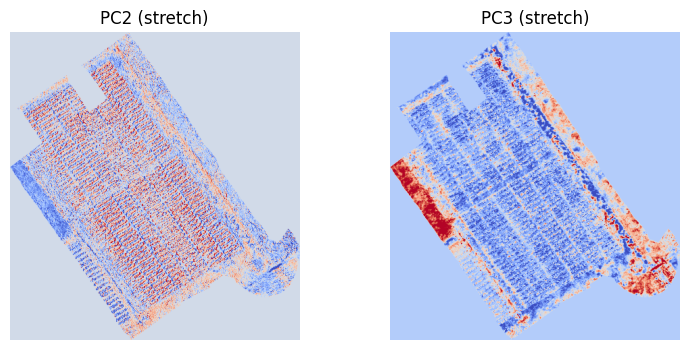

In [98]:
def stretch(img, p=(2,98)):
    lo, hi = np.nanpercentile(img, p)
    return np.clip((img - lo) / (hi - lo + 1e-6), 0, 1)

pcs_low = pcs_sel.coarsen(y=8, x=8, boundary="trim").mean().compute()
pc2_img = stretch(pcs_low.sel(pc=2).values)
pc3_img = stretch(pcs_low.sel(pc=3).values)

fig, ax = plt.subplots(1,2, figsize=(9,4))
ax[0].imshow(pc2_img, cmap="coolwarm"); ax[0].set_title("PC2 (stretch)")
ax[1].imshow(pc3_img, cmap="coolwarm"); ax[1].set_title("PC3 (stretch)")
for a in ax: a.axis("off")
plt.show()